In [2]:
!pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다.
np.random.seed(42)

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", stats.__name__)

준비 완료!
numpy : 2.4.6
pandas: 3.0.3
scipy : scipy.stats


In [3]:
# ─────────────────────────────────────────────
# [C2] 실습 데이터 로드 — 인터넷에서 받아오기
#   · tips / titanic / penguins : seaborn 내장 데이터셋
#       (seaborn-data GitHub 저장소에서 자동 다운로드 → 인터넷 필요)
#   · web_logs : 공개 데이터셋이 아니므로, 같은 통계적 성질
#       (포아송 방문자 · 이진 성공/실패)을 재현하도록 시드 고정 합성 생성
# ─────────────────────────────────────────────

# ── (1) seaborn 내장 실데이터 3종 ──
tips     = sns.load_dataset("tips")        # 식당 영수증(결제 금액·팁)
titanic  = sns.load_dataset("titanic")     # 타이타닉 승객(운임·나이)
penguins = sns.load_dataset("penguins")    # 펭귄 신체 측정(종·체중)

# ── (2) 웹 접속 로그(합성) ──
# 실제 로그 파일 대신, 분포 진단에 필요한 성질을 그대로 갖도록 생성합니다.
#   - 일별 '고유 방문자 수'가 포아송을 닮도록 (포아송 후보)
#   - status_code 의 성공(200) 비율이 일정하도록 (베타 후보)
rng = np.random.default_rng(42)            # 재현성: 시드 고정
n_days = 180
start  = pd.Timestamp("2024-01-01")

# 일별 고유 방문자 수를 먼저 포아송으로 확정 (var ≈ mean 성질 유지)
day_visitors = rng.poisson(150, size=n_days)

_frames = []
for d in range(n_days):
    n_vis    = int(day_visitors[d])                    # 그날 고유 방문자 수 → 포아송
    reqs_per = rng.integers(1, 14, size=n_vis)         # 방문자당 요청 수
    total    = int(reqs_per.sum())
    user_ids = np.repeat(np.arange(n_vis) + d * 10_000, reqs_per)   # 날짜별 고유 id
    secs     = rng.integers(0, 86_400, size=total)                  # 하루 중 초 단위 시각
    ts       = start + pd.Timedelta(days=d) + pd.to_timedelta(secs, unit="s")
    status   = np.where(rng.random(total) < 0.93, 200,             # 성공률 ≈ 0.93
                        rng.choice([404, 500, 503], size=total))
    resp     = rng.exponential(120, size=total)                    # 응답시간(ms) → 지수 형태
    _frames.append(pd.DataFrame({"ts": ts, "user_id": user_ids,
                                 "status_code": status, "response_ms": resp}))

web = (pd.concat(_frames, ignore_index=True)
         .sort_values("ts")
         .reset_index(drop=True))
web["date"] = web["ts"].dt.date

# 일별 '고유 방문자 수' — 독립적으로 드물게 일어나는 사건의 합 → 포아송 후보
visitors = web.groupby("date")["user_id"].nunique()

print("로드 완료 ✓  (tips·titanic·penguins: seaborn 인터넷 다운로드 / web: 합성)")
print(f"  tips     {tips.shape}  · 식당 영수증")
print(f"  titanic  {titanic.shape} · 승객 (운임·나이)")
print(f"  penguins {penguins.shape}   · 펭귄 (종·체중)")
print(f"  web      {web.shape} · 웹 로그 → 일별 방문자 {len(visitors)}일치")
titanic.head()

로드 완료 ✓  (tips·titanic·penguins: seaborn 인터넷 다운로드 / web: 합성)
  tips     (244, 7)  · 식당 영수증
  titanic  (891, 15) · 승객 (운임·나이)
  penguins (344, 7)   · 펭귄 (종·체중)
  web      (188022, 5) · 웹 로그 → 일별 방문자 180일치


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# [C3] 예제 1.1: 평균·중앙값·표준편차·IQR — pandas로 한 번에
fare = titanic["fare"].dropna()
print(f"타이타닉 운임(fare) 표본 크기 n = {len(fare)}")
print(f"표본평균 x̄ = {fare.mean():,.2f}")
print(f"중앙값   = {fare.median():,.2f}")
print(f"표본표준편차 s = {fare.std():,.2f}")
print(f"Q1 = {fare.quantile(0.25):,.2f}")
print(f"Q3 = {fare.quantile(0.75):,.2f}")
print(f"IQR = Q3 - Q1 = {fare.quantile(0.75) - fare.quantile(0.25):,.2f}")
print(f"최솟값 = {fare.min():,.2f}, 최댓값 = {fare.max():,.2f}")

타이타닉 운임(fare) 표본 크기 n = 891
표본평균 x̄ = 32.20
중앙값   = 14.45
표본표준편차 s = 49.69
Q1 = 7.91
Q3 = 31.00
IQR = Q3 - Q1 = 23.09
최솟값 = 0.00, 최댓값 = 512.33


In [5]:
# [C4] 예제 1.2: describe() — 한 번에 보기 (운임 vs 나이)
titanic[["fare", "age"]].describe().round(2)

,fare,age
count,891.00,714.00
mean,32.20,29.70
std,49.69,14.53
min,0.00,0.42
25%,7.91,20.12
50%,14.45,28.00
75%,31.00,38.00
max,512.33,80.00


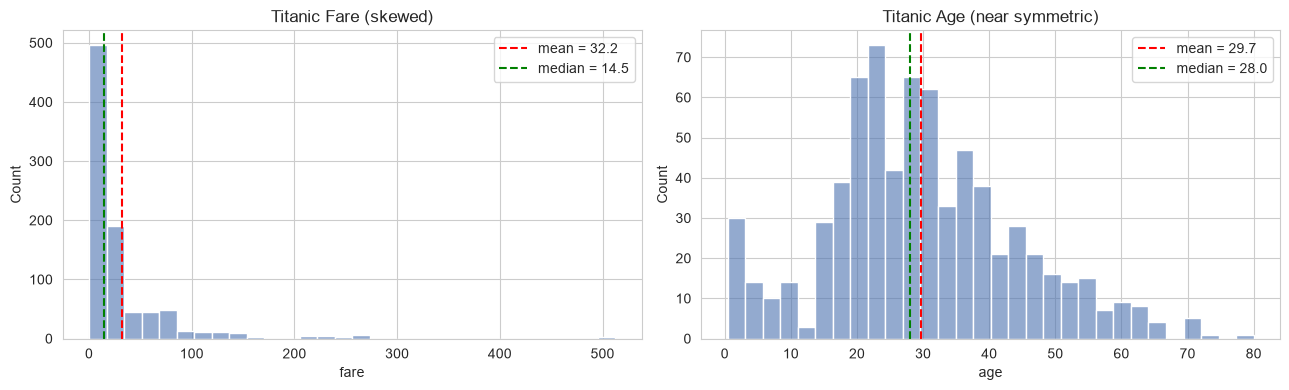

In [6]:
# [C5] 예제 1.3: 평균과 중앙값을 그림에 함께 — 분포가 한쪽으로 치우치면 두 값이 갈라진다
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
                          ["fare", "age"],
                          ["Titanic Fare (skewed)", "Titanic Age (near symmetric)"]):
    s = titanic[col].dropna()
    sns.histplot(s, bins=30, ax=ax, color="#4C72B0", alpha=0.6)
    ax.axvline(s.mean(),   color="red",   linestyle="--", label=f"mean = {s.mean():,.1f}")
    ax.axvline(s.median(), color="green", linestyle="--", label=f"median = {s.median():,.1f}")
    ax.set_title(title)
    ax.legend()

plt.tight_layout(); plt.show()

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 데이터 로드 (위 셀에서 이미 생성된 변수 재사용) ──

# ──────────────────────────────────────────────
# 1) visitors 기술통계: 평균·중앙값·표준편차·IQR
# ──────────────────────────────────────────────
v_mean   = visitors.mean()
v_median = visitors.median()
v_std    = visitors.std()
v_q1, v_q3 = visitors.quantile(0.25), visitors.quantile(0.75)
v_iqr    = v_q3 - v_q1

print("=" * 50)
print("1) 일별 고유 방문자 수(visitors) 기술통계")
print("=" * 50)
print(f"  평균     : {v_mean:.2f}")
print(f"  중앙값   : {v_median:.2f}")
print(f"  표준편차 : {v_std:.2f}")
print(f"  IQR      : {v_iqr:.2f}  (Q1={v_q1:.1f}, Q3={v_q3:.1f})")
print(f"  [포아송 체크] 평균≈분산?  분산={v_std**2:.2f}, 평균={v_mean:.2f}")

# ──────────────────────────────────────────────
# 2) 변동계수(CV) 비교: titanic fare vs tips total_bill
#    CV = 표준편차 / 평균  (단위 없는 상대적 흩어짐)
# ──────────────────────────────────────────────
fare_mean, fare_std = titanic["fare"].mean(), titanic["fare"].std()
bill_mean, bill_std = tips["total_bill"].mean(), tips["total_bill"].std()
fare_cv = fare_std / fare_mean
bill_cv = bill_std / bill_mean

print("\n" + "=" * 50)
print("2) 변동계수(CV) 비교")
print("=" * 50)
print(f"  {'':12} {'평균':>8} {'표준편차':>10} {'CV':>8}")
print(f"  {'titanic fare':12} {fare_mean:>8.2f} {fare_std:>10.2f} {fare_cv:>8.4f}")
print(f"  {'tips bill':12} {bill_mean:>8.2f} {bill_std:>10.2f} {bill_cv:>8.4f}")
print(f"\n  fare CV({fare_cv:.2f}) > bill CV({bill_cv:.2f})")
print(f"  → fare가 {fare_cv/bill_cv:.1f}배 더 흔들림")

# ──────────────────────────────────────────────
# 3) 같은 평균, 다른 표준편차 → 예측 어려운 쪽 판단
#    fare와 bill 평균이 다르지만, CV로 "상대적 불확실성" 비교 가능
#    아래는 '개념 확인용' 합성 예시도 추가
# ──────────────────────────────────────────────

# 개념 확인: 평균 동일, 표준편차만 다른 두 데이터
np.random.seed(2025)
A = np.random.normal(loc=20, scale=2,  size=500)   # 안정적
B = np.random.normal(loc=20, scale=10, size=500)   # 불안정

print("\n" + "=" * 50)
print("3) 같은 평균, 다른 표준편차 — 예측 난이도 비교")
print("=" * 50)
print(f"  데이터 A: 평균 {A.mean():.2f} | 표준편차 {A.std():.2f} | CV {A.std()/A.mean():.3f}")
print(f"  데이터 B: 평균 {B.mean():.2f} | 표준편차 {B.std():.2f} | CV {B.std()/B.mean():.3f}")

pct_A = np.mean(np.abs(A - A.mean()) < A.std()) * 100
pct_B = np.mean(np.abs(B - B.mean()) < B.std()) * 100
print(f"\n  평균 ±1σ 이내 비율 — A: {pct_A:.1f}%  B: {pct_B:.1f}%")
print(f"  A의 '±5 벗어날 확률' : {np.mean(np.abs(A-20)>5)*100:.1f}%")
print(f"  B의 '±5 벗어날 확률' : {np.mean(np.abs(B-20)>5)*100:.1f}%")

1) 일별 고유 방문자 수(visitors) 기술통계
  평균     : 149.64
  중앙값   : 149.00
  표준편차 : 12.22
  IQR      : 18.25  (Q1=141.0, Q3=159.2)
  [포아송 체크] 평균≈분산?  분산=149.34, 평균=149.64

2) 변동계수(CV) 비교
                     평균       표준편차       CV
  titanic fare    32.20      49.69   1.5431
  tips bill       19.79       8.90   0.4499

  fare CV(1.54) > bill CV(0.45)
  → fare가 3.4배 더 흔들림

3) 같은 평균, 다른 표준편차 — 예측 난이도 비교
  데이터 A: 평균 19.88 | 표준편차 1.93 | CV 0.097
  데이터 B: 평균 19.97 | 표준편차 9.59 | CV 0.480

  평균 ±1σ 이내 비율 — A: 67.6%  B: 69.8%
  A의 '±5 벗어날 확률' : 0.4%
  B의 '±5 벗어날 확률' : 58.8%


In [8]:
def summarize_shape(named_series):
    rows = []
    for name, s in named_series:
        s = s.dropna()
        rows.append({
            "변수": name,
            "평균": s.mean(),
            "중앙값": s.median(),
            "표준편차": s.std(),
            "왜도(skew)": stats.skew(s),
            "첨도(kurt)": stats.kurtosis(s),
        })
    return pd.DataFrame(rows).round(2)

shape_table = summarize_shape([
    ("titanic.fare",            titanic["fare"]),
    ("tips.total_bill",         tips["total_bill"]),
    ("titanic.age",             titanic["age"]),
    ("penguins.body_mass_g",    penguins["body_mass_g"]),
    ("penguins.flipper_len_mm", penguins["flipper_length_mm"]),
])
shape_table

,변수,평균,중앙값,표준편차,왜도(skew),첨도(kurt)
0,titanic.fare,32.20,14.45,49.69,4.78,33.20
1,tips.total_bill,19.79,17.80,8.90,1.13,1.17
2,titanic.age,29.70,28.00,14.53,0.39,0.17
3,penguins.body_mass_g,4201.75,4050.00,801.95,0.47,-0.73
4,penguins.flipper_len_mm,200.92,197.00,14.06,0.34,-0.99


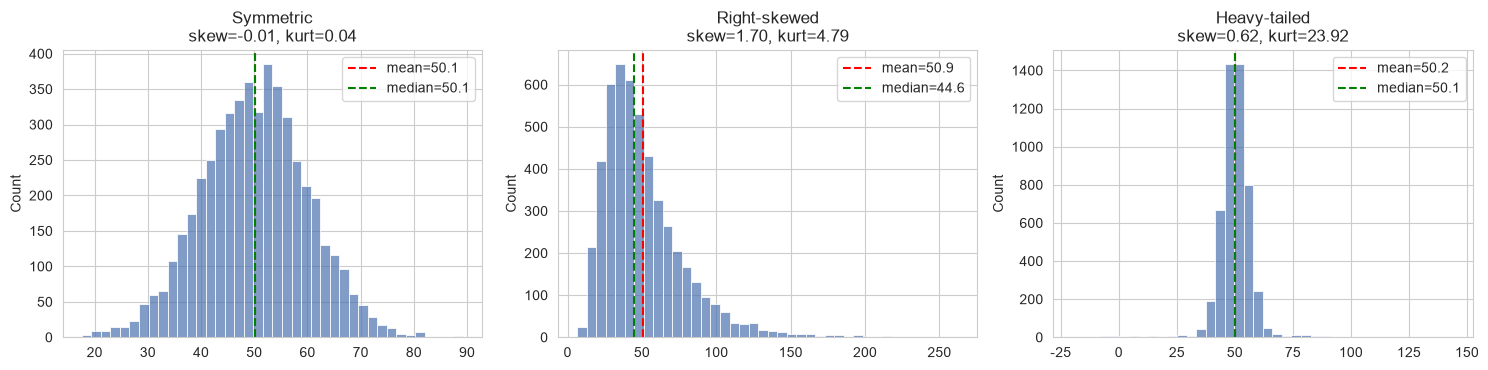

세 분포의 평균은 거의 같지만 모양은 전혀 다릅니다.


In [9]:
# [C8] 예제 2.2: 같은 평균인데 다른 모양 — 인공 데이터 세 개
np.random.seed(42)
N = 5000
sym  = np.random.normal(loc=50, scale=10, size=N)              # 좌우 대칭
right = np.random.lognormal(mean=np.log(45), sigma=0.5, size=N) # 우편향
heavy = np.concatenate([
    np.random.normal(loc=50, scale=5,  size=int(N*0.95)),
    np.random.normal(loc=50, scale=30, size=int(N*0.05)),       # 5% 극단값
])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, data, name in zip(axes,
                          [sym, right, heavy],
                          ["Symmetric", "Right-skewed", "Heavy-tailed"]):
    sns.histplot(data, bins=40, ax=ax, color="#4C72B0", alpha=0.7)
    ax.axvline(np.mean(data), color="red",   linestyle="--",
               label=f"mean={np.mean(data):.1f}")
    ax.axvline(np.median(data), color="green", linestyle="--",
               label=f"median={np.median(data):.1f}")
    ax.set_title(f"{name}\nskew={stats.skew(data):.2f}, kurt={stats.kurtosis(data):.2f}")
    ax.legend()
plt.tight_layout(); plt.show()

print("세 분포의 평균은 거의 같지만 모양은 전혀 다릅니다.")

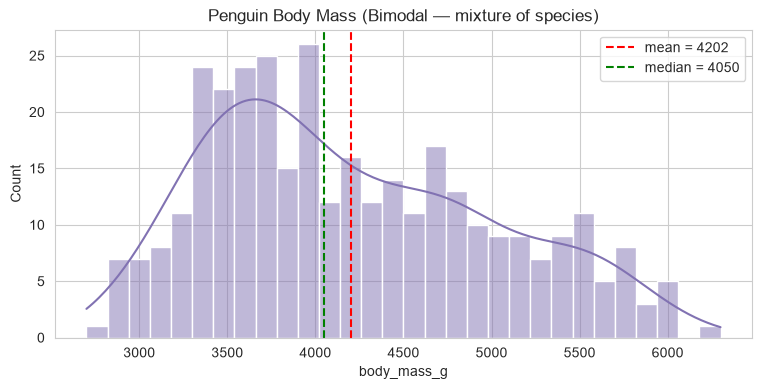

왜도: 0.47
첨도: -0.73  (음수 → 납작/다봉 신호)
→ 왜도가 0에 가깝다고 해서 정규분포라는 뜻은 아닙니다!


In [10]:
# [C9] 예제 2.3: 다봉 분포 — '평균'이 어디에도 없는 값일 때
bm = penguins["body_mass_g"].dropna()
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(bm, bins=30, kde=True, ax=ax, color="#8172B2")
ax.axvline(bm.mean(),   color="red",   linestyle="--", label=f"mean = {bm.mean():.0f}")
ax.axvline(bm.median(), color="green", linestyle="--", label=f"median = {bm.median():.0f}")
ax.set_title("Penguin Body Mass (Bimodal — mixture of species)")
ax.set_xlabel("body_mass_g")
ax.legend(); plt.show()

print(f"왜도: {stats.skew(bm):.2f}")
print(f"첨도: {stats.kurtosis(bm):.2f}  (음수 → 납작/다봉 신호)")
print("→ 왜도가 0에 가깝다고 해서 정규분포라는 뜻은 아닙니다!")

In [11]:
from scipy.stats import skew, kurtosis

# ─────────────────────────────────────────────
# 1) titanic["fare"] 왜도·첨도
# ─────────────────────────────────────────────
fare     = titanic["fare"].dropna()
log_fare = np.log1p(fare)           # log(1+x): 0원짜리 처리 가능

skew_fare  = skew(fare)
kurt_fare  = kurtosis(fare)         # scipy 기본: 초과첨도 (정규분포=0)

print("=" * 52)
print("1) titanic fare 왜도·첨도")
print("=" * 52)
print(f"  왜도  : {skew_fare:.4f}   (양의 왜도 — 오른쪽 꼬리)")
print(f"  첨도  : {kurt_fare:.4f}   (정규분포 초과 첨도 = 0 기준)")
print(f"  평균  : {fare.mean():.2f}  중앙값 : {fare.median():.2f}")
print(f"  최솟값: {fare.min():.2f}  최댓값 : {fare.max():.2f}")
print(f"  0원 승객: {(fare==0).mean()*100:.1f}%  |  100원 초과: {(fare>100).mean()*100:.1f}%")

# ─────────────────────────────────────────────
# 2) 로그 변환 후 왜도 비교
# ─────────────────────────────────────────────
skew_log  = skew(log_fare)
kurt_log  = kurtosis(log_fare)

print("\n" + "=" * 52)
print("2) 로그 변환 전후 비교")
print("=" * 52)
print(f"  {'':12} {'원본 fare':>12} {'log1p(fare)':>12} {'감소율':>8}")
print(f"  {'왜도':12} {skew_fare:>12.4f} {skew_log:>12.4f} {(skew_fare-skew_log)/skew_fare*100:>7.1f}%")
print(f"  {'첨도':12} {kurt_fare:>12.4f} {kurt_log:>12.4f} {(kurt_fare-kurt_log)/kurt_fare*100:>7.1f}%")
print(f"  {'평균':12} {fare.mean():>12.3f} {log_fare.mean():>12.3f}")
print(f"  {'중앙값':12} {fare.median():>12.3f} {log_fare.median():>12.3f}")
print(f"  {'(평균-중앙값)':12} {fare.mean()-fare.median():>12.3f} {log_fare.mean()-log_fare.median():>12.3f}")

# ─────────────────────────────────────────────
# 3) 왜도≈0, 첨도 매우 큰 분포 — 추정 및 근거
# ─────────────────────────────────────────────
print("\n" + "=" * 52)
print("3) 왜도≈0 & 첨도 매우 큰 분포")
print("=" * 52)
print("  → 코드 내 주석(docstring) 참고")

1) titanic fare 왜도·첨도
  왜도  : 4.7793   (양의 왜도 — 오른쪽 꼬리)
  첨도  : 33.2043   (정규분포 초과 첨도 = 0 기준)
  평균  : 32.20  중앙값 : 14.45
  최솟값: 0.00  최댓값 : 512.33
  0원 승객: 1.7%  |  100원 초과: 5.9%

2) 로그 변환 전후 비교
                    원본 fare  log1p(fare)      감소율
  왜도                 4.7793       0.3943    91.8%
  첨도                33.2043       0.9639    97.1%
  평균                 32.204        2.962
  중앙값                14.454        2.738
  (평균-중앙값)           17.750        0.224

3) 왜도≈0 & 첨도 매우 큰 분포
  → 코드 내 주석(docstring) 참고


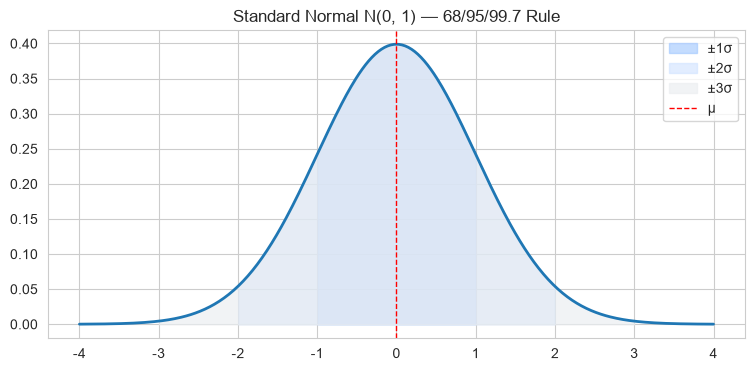

±1σ 안 확률: 0.683
±2σ 안 확률: 0.954
±3σ 안 확률: 0.997


In [12]:
# [C11] 예제 3.1: 정규분포 PDF — 68-95-99.7 규칙
mu, sigma = 0, 1
x = np.linspace(-4, 4, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, pdf, lw=2)
for k, color in zip([1, 2, 3], ["#9ec5fe", "#cfe2ff", "#e9ecef"]):
    ax.fill_between(x, pdf, where=(x >= -k) & (x <= k), color=color, alpha=0.6,
                    label=f"±{k}σ")
ax.axvline(mu, color="red", linestyle="--", lw=1, label="μ")
ax.set_title("Standard Normal N(0, 1) — 68/95/99.7 Rule")
ax.legend(); plt.show()

print("±1σ 안 확률:", round(stats.norm.cdf(1) - stats.norm.cdf(-1), 3))
print("±2σ 안 확률:", round(stats.norm.cdf(2) - stats.norm.cdf(-2), 3))
print("±3σ 안 확률:", round(stats.norm.cdf(3) - stats.norm.cdf(-3), 3))

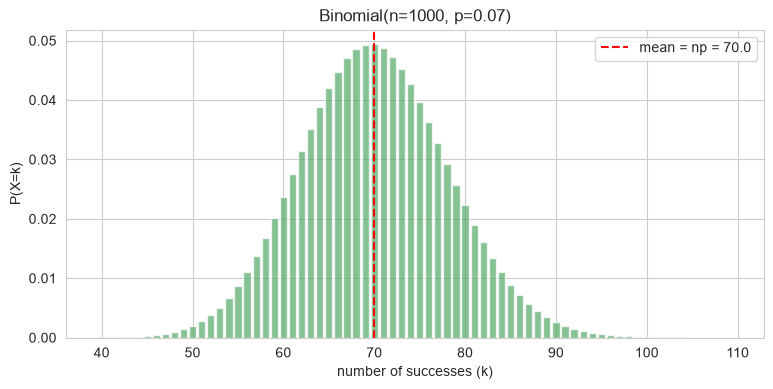

이론 평균(np): 70.0, 표본평균: 69.6
이론 표준편차: 8.07, 표본표준편차: 8.07


In [13]:
# [C12] 예제 3.2: 이항분포 — n=1000, p=0.07 (쿠폰 사용 횟수)
n_trials, p = 1000, 0.07
x = np.arange(40, 110)
pmf = stats.binom.pmf(x, n_trials, p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, pmf, color="#55A868", alpha=0.7)
ax.axvline(n_trials * p, color="red", linestyle="--", label=f"mean = np = {n_trials*p}")
ax.set_title(f"Binomial(n={n_trials}, p={p})")
ax.set_xlabel("number of successes (k)"); ax.set_ylabel("P(X=k)")
ax.legend(); plt.show()

# 같은 분포에서 표본을 뽑아 이론과 비교 (시뮬레이션, seed 고정)
sample = stats.binom.rvs(n_trials, p, size=365, random_state=42)
print(f"이론 평균(np): {n_trials*p:.1f}, 표본평균: {sample.mean():.1f}")
print(f"이론 표준편차: {np.sqrt(n_trials*p*(1-p)):.2f}, 표본표준편차: {sample.std():.2f}")

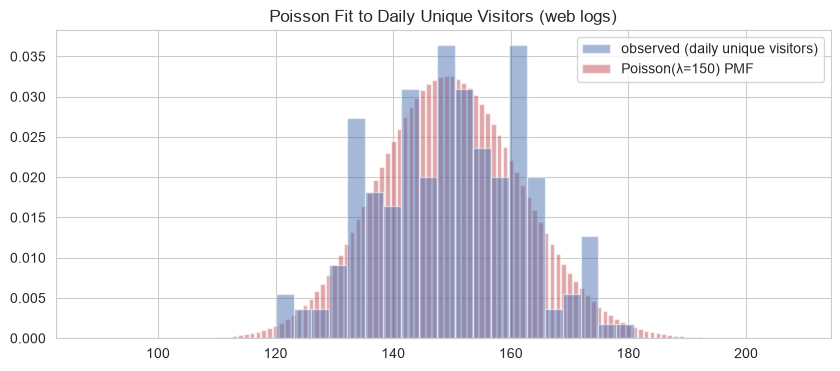

포아송 가정 점검: 평균 ≈ 분산?
표본평균: 149.6
표본분산: 149.3
분산/평균 비 = 1.00  (1에 가까울수록 포아송 닮음)


In [14]:
# [C13] 예제 3.3: 포아송 — 웹로그 '일별 고유 방문자 수' 실데이터와 비교
lam = visitors.mean()
span = max(60, int(3 * np.sqrt(lam)))
x = np.arange(max(0, int(lam - span)), int(lam + span))
pmf = stats.poisson.pmf(x, lam)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, pmf, color="#C44E52", alpha=0.5, label=f"Poisson(λ={lam:.0f}) PMF")
ax.hist(visitors, bins=20, density=True, alpha=0.5,
        color="#4C72B0", label="observed (daily unique visitors)")
ax.set_title("Poisson Fit to Daily Unique Visitors (web logs)")
ax.legend(); plt.show()

print("포아송 가정 점검: 평균 ≈ 분산?")
print(f"표본평균: {visitors.mean():.1f}")
print(f"표본분산: {visitors.var():.1f}")
print(f"분산/평균 비 = {visitors.var()/visitors.mean():.2f}  (1에 가까울수록 포아송 닮음)")

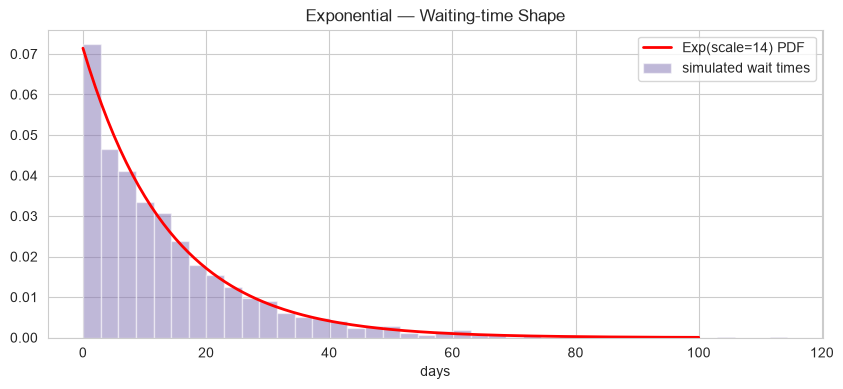

지수분포의 특성: 평균 ≈ 표준편차
표본평균: 14.05
표본표준편차: 14.15


In [15]:
# [C14] 예제 3.4: 지수분포 — '재구매까지 일수' (대기시간, 시뮬레이션·seed 고정)
# 지수분포는 사건 사이 '대기시간'의 모형 — 깔끔한 형태를 보이려 통제 생성합니다.
wait = stats.expon.rvs(scale=14, size=2000, random_state=42)   # 평균 14일
x = np.linspace(0, 100, 200)
pdf = stats.expon.pdf(x, scale=14)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, pdf, color="red", lw=2, label="Exp(scale=14) PDF")
ax.hist(wait, bins=40, density=True, alpha=0.5,
        color="#8172B2", label="simulated wait times")
ax.set_title("Exponential — Waiting-time Shape")
ax.set_xlabel("days"); ax.legend(); plt.show()

print("지수분포의 특성: 평균 ≈ 표준편차")
print(f"표본평균: {wait.mean():.2f}")
print(f"표본표준편차: {wait.std():.2f}")

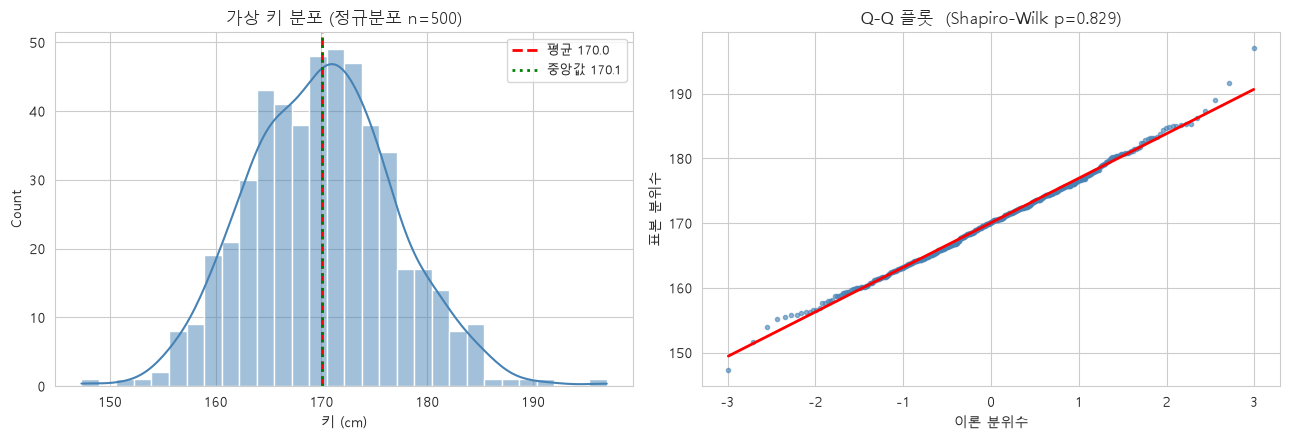

1) 키 데이터 (정규분포 loc=170, scale=7, n=500)
  평균 170.0479 | 중앙값 170.0896 | 차이 -0.0417
  표준편차 6.8619  (이론 7.0)
  왜도 0.1796  첨도 0.2564  (정규분포 기준 0)
  Shapiro-Wilk W=0.9956, p=0.8290  → 정규성 유지
  범위 147.3 ~ 197.0


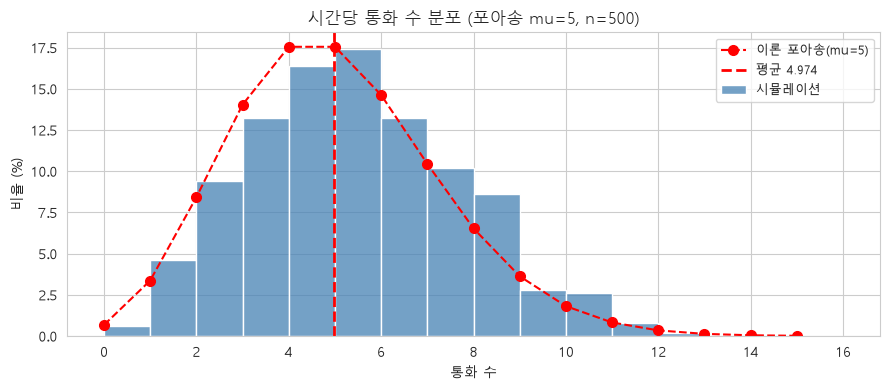


2) 통화 수 (포아송 mu=5, n=500)
                     실측         이론         차이
  평균             4.9740     5.0000    -0.0260
  분산             5.2213     5.0000    +0.2213
  왜도             0.3086     0.4472
  평균≈분산 차이: 0.2473  (n=500 몬테카를로 오차 수준)


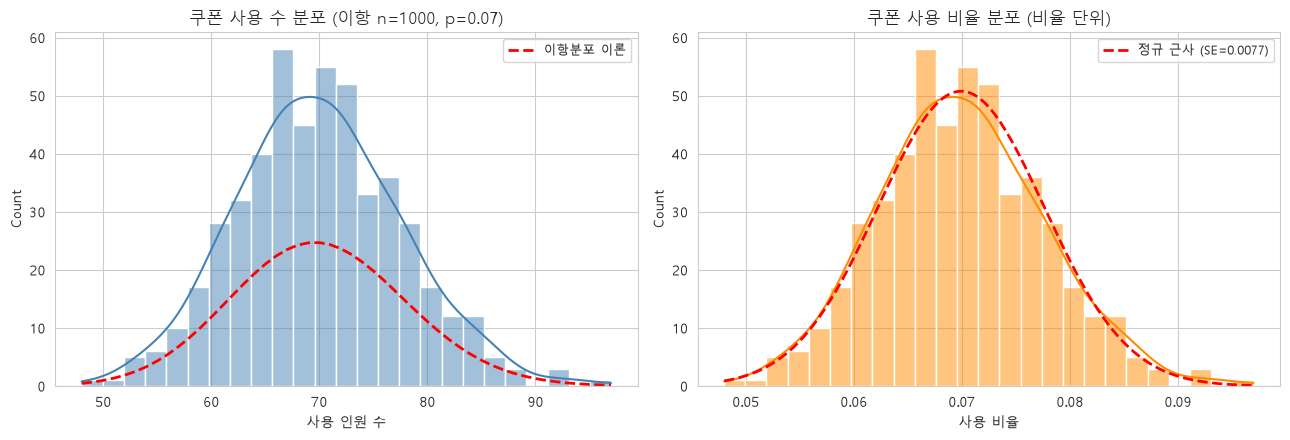


3) 쿠폰 사용 수·비율 분포
  [사용 수] 평균 69.93 (이론 70.0)
           분산 59.32 (이론 65.10)
           왜도 0.2132 (이론 0.1066)
  [비율]   평균 0.0699 (이론 0.07)
           표준편차 0.0077 (이론 SE=0.0081)
  포아송 근사 가능? np=70.0≥30 → 가능하지만 이항이 더 정확


In [16]:

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ─────────────────────────────────────────────
# 1) 정규분포 — 가상 키 데이터 500명
# ─────────────────────────────────────────────
np.random.seed(42)
height = stats.norm.rvs(loc=170, scale=7, size=500)

W, p_sw = stats.shapiro(height[:200])      # Shapiro-Wilk (n≤200 권장)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
sns.histplot(height, bins=30, kde=True, color='steelblue', ax=ax)
ax.axvline(height.mean(), color='red',    linestyle='--', lw=2, label=f'평균 {height.mean():.1f}')
ax.axvline(np.median(height), color='green', linestyle=':', lw=2, label=f'중앙값 {np.median(height):.1f}')
ax.set_title('가상 키 분포 (정규분포 n=500)')
ax.set_xlabel('키 (cm)')
ax.legend(fontsize=9)

ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(height, dist='norm')
ax.plot(osm, osr, 'o', ms=3, color='steelblue', alpha=0.6)
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2)
ax.set_title(f'Q-Q 플롯  (Shapiro-Wilk p={p_sw:.3f})')
ax.set_xlabel('이론 분위수'); ax.set_ylabel('표본 분위수')

plt.tight_layout()
plt.show()

print("=" * 52)
print("1) 키 데이터 (정규분포 loc=170, scale=7, n=500)")
print("=" * 52)
print(f"  평균 {height.mean():.4f} | 중앙값 {np.median(height):.4f} | 차이 {height.mean()-np.median(height):+.4f}")
print(f"  표준편차 {height.std():.4f}  (이론 7.0)")
print(f"  왜도 {stats.skew(height):.4f}  첨도 {stats.kurtosis(height):.4f}  (정규분포 기준 0)")
print(f"  Shapiro-Wilk W={W:.4f}, p={p_sw:.4f}  → 정규성 {'유지' if p_sw>=0.05 else '기각'}")
print(f"  범위 {height.min():.1f} ~ {height.max():.1f}")

# ─────────────────────────────────────────────
# 2) 포아송 — 시간당 통화 수 (mu=5, n=500)
# ─────────────────────────────────────────────
calls = stats.poisson.rvs(mu=5, size=500, random_state=42)

fig, ax = plt.subplots(figsize=(9, 4))
x_theory = np.arange(0, 16)
p_theory  = stats.poisson.pmf(x_theory, mu=5) * 100

sns.histplot(calls, bins=range(0, 17), stat='percent',
             color='steelblue', ax=ax, label='시뮬레이션')
ax.plot(x_theory, p_theory, 'ro--', ms=7, lw=1.5, label='이론 포아송(mu=5)')
ax.axvline(calls.mean(), color='red', linestyle='--', lw=2,
           label=f'평균 {calls.mean():.3f}')
ax.set_title('시간당 통화 수 분포 (포아송 mu=5, n=500)')
ax.set_xlabel('통화 수'); ax.set_ylabel('비율 (%)'); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "=" * 52)
print("2) 통화 수 (포아송 mu=5, n=500)")
print("=" * 52)
print(f"  {'':10} {'실측':>10} {'이론':>10} {'차이':>10}")
print(f"  {'평균':10} {calls.mean():>10.4f} {5.0:>10.4f} {calls.mean()-5:>+10.4f}")
print(f"  {'분산':10} {calls.var():>10.4f} {5.0:>10.4f} {calls.var()-5:>+10.4f}")
print(f"  {'왜도':10} {stats.skew(calls):>10.4f} {1/np.sqrt(5):>10.4f}")
print(f"  평균≈분산 차이: {abs(calls.mean()-calls.var()):.4f}  (n=500 몬테카를로 오차 수준)")

# ─────────────────────────────────────────────
# 3) 쿠폰 사용 — 이항 vs 포아송 vs 베타
# ─────────────────────────────────────────────
np.random.seed(2025)
coupons = stats.binom.rvs(n=1000, p=0.07, size=500)
rates   = coupons / 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
sns.histplot(coupons, bins=25, kde=True, color='steelblue', ax=ax)
x_b = np.arange(coupons.min(), coupons.max()+1)
ax.plot(x_b, stats.binom.pmf(x_b, n=1000, p=0.07)*500,
        'r--', lw=2, label='이항분포 이론')
ax.set_title('쿠폰 사용 수 분포 (이항 n=1000, p=0.07)')
ax.set_xlabel('사용 인원 수'); ax.legend(fontsize=9)

ax = axes[1]
sns.histplot(rates, bins=25, kde=True, color='darkorange', ax=ax)
x_r = np.linspace(rates.min(), rates.max(), 200)
ax.plot(x_r, stats.norm.pdf(x_r, rates.mean(), rates.std())*500*(rates.max()-rates.min())/25,
        'r--', lw=2, label=f'정규 근사 (SE={rates.std():.4f})')
ax.set_title('쿠폰 사용 비율 분포 (비율 단위)')
ax.set_xlabel('사용 비율'); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "=" * 52)
print("3) 쿠폰 사용 수·비율 분포")
print("=" * 52)
print(f"  [사용 수] 평균 {coupons.mean():.2f} (이론 {1000*0.07:.1f})")
print(f"           분산 {coupons.var():.2f} (이론 {1000*0.07*0.93:.2f})")
print(f"           왜도 {stats.skew(coupons):.4f} (이론 {(1-2*0.07)/np.sqrt(1000*0.07*0.93):.4f})")
print(f"  [비율]   평균 {rates.mean():.4f} (이론 0.07)")
print(f"           표준편차 {rates.std():.4f} (이론 SE={np.sqrt(0.07*0.93/1000):.4f})")
print(f"  포아송 근사 가능? np={1000*0.07}≥30 → 가능하지만 이항이 더 정확")